In [17]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

y_pred = np.zeros(len(X_test))

for k in [1, 3, 5, 7, 9]:
    y_pred = np.zeros(len(X_test))
    for i in range(len(X_test)):
    
        distances = np.sqrt(np.sum((X_train_scaled - X_test_scaled[i]) ** 2, axis=1))
    
        nearest_indices = np.argsort(distances)[:k]
    
        nearest_labels = y_train[nearest_indices]
    
        prediction = np.bincount(nearest_labels).argmax()
    
        y_pred[i] = prediction
    
    
    accuracy = np.mean(y_pred == y_test)
    print('for k = ', k ," Accuracy:", accuracy)

for k =  1  Accuracy: 0.9629629629629629
for k =  3  Accuracy: 0.9444444444444444
for k =  5  Accuracy: 0.9444444444444444
for k =  7  Accuracy: 0.9444444444444444
for k =  9  Accuracy: 0.9629629629629629


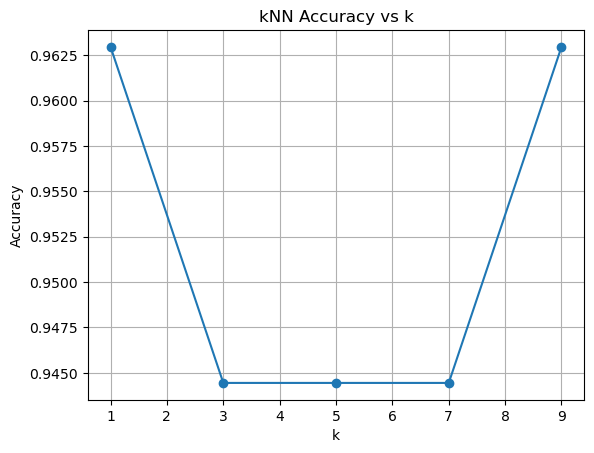

In [19]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("kNN Accuracy vs k")
plt.grid(True)
plt.show()

In [23]:
results = {}

for k in [1, 3, 5, 7, 9]:

    y_pred = np.zeros(len(X_test))

    for i in range(len(X_test)):

        distances = np.sqrt(np.sum((X_train_scaled - X_test_scaled[i]) ** 2, axis=1))

        nearest_indices = np.argsort(distances)[:k]

        nearest_labels = y_train[nearest_indices]

        prediction = np.bincount(nearest_labels).argmax()

        y_pred[i] = prediction

    # accuracy
    accuracy = np.mean(y_pred == y_test)

    # DataFrame comparison
    df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_pred.astype(int),
        "correct": y_test == y_pred
    })

    results[k] = {
        "accuracy": accuracy,
        "df": df
    }

    print(f"\nk = {k} | Accuracy = {accuracy:.4f}")
    print(df.head(10))


k = 1 | Accuracy = 0.9630
   y_true  y_pred  correct
0       0       0     True
1       1       1     True
2       0       0     True
3       0       0     True
4       0       0     True
5       0       0     True
6       2       2     True
7       1       1     True
8       1       0    False
9       2       2     True

k = 3 | Accuracy = 0.9444
   y_true  y_pred  correct
0       0       0     True
1       1       1     True
2       0       0     True
3       0       0     True
4       0       0     True
5       0       0     True
6       2       2     True
7       1       1     True
8       1       0    False
9       2       2     True

k = 5 | Accuracy = 0.9444
   y_true  y_pred  correct
0       0       0     True
1       1       1     True
2       0       0     True
3       0       0     True
4       0       0     True
5       0       0     True
6       2       2     True
7       1       1     True
8       1       1     True
9       2       2     True

k = 7 | Accuracy = 0.9444
 